# Pipeline development – end-to-end and testable

**How to use:**
- Run **Config** and **Load models** once per session.
- Then either run **"Run full pipeline"** (one cell) or run **Steps 1–7** in order for step-by-step execution.
- To test a specific part: change parameters and re-run from that step (e.g. re-run from Direction change or Speed); no need to re-load models or re-run heavy detection steps.
- Set `TASK_ID = None` for no DB writes; set a valid task id when you want to persist to the database.

In [6]:
# Config – run once, then run "Load models" and either full pipeline or steps 1–7
import os

VIDEO_PATH = "./f05ee009-23c0-49ae-a50d-4822c2543cc3.mp4"  # required
DEVICE = "cpu"  # or "cpu"
TASK_ID = None   # None = no DB; set to an int to write to DB
OUTPUT_DIR = "output"
os.makedirs(OUTPUT_DIR, exist_ok=True)

In [2]:
# Imports
import time
import cv2
import numpy as np
from collections import defaultdict
from scipy.spatial.distance import euclidean

from src.core.ball_detector import BallDetector
from src.core.bounce_detector import BounceDetector
from src.core.court_detection_net import CourtDetectorNet
from src.core.person_detector import PersonDetector
from src.core.process_video import (
    process_video,
    get_detections_from_video,
    get_valid_scenes,
    get_sources_from_source_indices,
    get_shot_type,
    cleanup_memory,
)
from src.core.get_direction_change_indices import get_direction_change_indices
from src.core.utils import (
    get_court_img,
    generate_player_heatmap,
    perspective_transform_point,
    scene_detect,
)
from src.schemas.speed_at import SpeedAt
from src.db.utils import (
    save_ball_track_in_db,
    save_bounces_in_db,
    save_direction_change_indices_in_db,
    save_player_positions_in_db,
    save_speed_in_db,
    save_thumbnail_in_db,
    save_video_paths_in_db,
)
import matplotlib.pyplot as plt

/home/mohiuddin/Documents/fyp_project/fyp_tennis_backend/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# Load models – run once per session
ball_detector = BallDetector("./src/track_net_weights.pt", DEVICE)
court_detector = CourtDetectorNet("./src/model_tennis_court_det.pt", DEVICE)
person_detector = PersonDetector(DEVICE)
bounce_detector = BounceDetector("./src/ctb_regr_bounce.cbm")
print(f"Models loaded on {DEVICE}.")

Models loaded on cpu.


## Preloaded Frame List for displaying results

In [7]:
cap = cv2.VideoCapture(VIDEO_PATH)
all_frames = []

while cap.isOpened():
    ret, frame = cap.read()
    if not ret or frame is None:
        break
    # frames in 720p
    frame = cv2.resize(frame, (1280, 720))
    all_frames.append(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
cap.release()

## Step 1: Scene detection

VideoManager is deprecated and will be removed.
`base_timecode` argument is deprecated and has no effect.


Scenes: [[0, 466]]


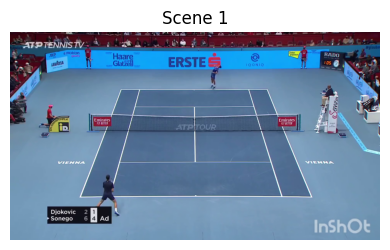

In [8]:
scenes = scene_detect(VIDEO_PATH)
print("Scenes:", scenes)

if scenes:
    max_diff = max(scenes, key=lambda x: x[1] - x[0])
    thumbnail_index = max_diff[0]
else:
    thumbnail_index = 0

# show each scene's first frame in the notebook with matplotlib
if not scenes:
    print("No scenes detected.")
else:
    import math

    valid_scenes = [(idx, scene) for idx, scene in enumerate(scenes) if 0 <= scene[0] < len(all_frames)]

    if not valid_scenes:
        print("No scene start frames are within loaded frame range.")
    else:
        skipped = len(scenes) - len(valid_scenes)
        if skipped:
            print(f"Skipped {skipped} scenes with out-of-range start frames.")

        num_scenes = len(valid_scenes)
        ncols = min(4, num_scenes)
        nrows = math.ceil(num_scenes / ncols)

        fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3 * nrows))
        if hasattr(axes, "flatten"):
            axes = axes.flatten()
        else:
            axes = [axes]

        for plot_idx, (scene_idx, scene) in enumerate(valid_scenes):
            axes[plot_idx].imshow(all_frames[scene[0]])
            axes[plot_idx].set_title(f"Scene {scene_idx + 1}")
            axes[plot_idx].axis("off")

        for ax in axes[num_scenes:]:
            ax.axis("off")

        plt.tight_layout()
        plt.show()

### inside function stuff

In [ ]:
# function really simple no need to change

## Step 2: Valid scenes (court filter)

[INFO]: Scene [0, 466] - court detected (valid)
Valid scenes: 1 / 1


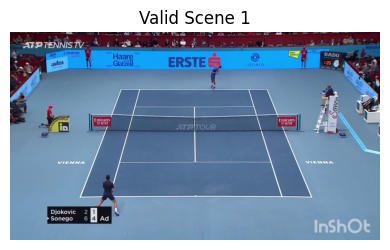

In [9]:
valid_scenes = get_valid_scenes(court_detector, VIDEO_PATH, scenes)
print(f"Valid scenes: {len(valid_scenes)} / {len(scenes)}")

# show each valid scene's first frame in the notebook with matplotlib
if not valid_scenes:
    print("No valid scenes detected.")
else:
    import math
    num_valid_scenes = len(valid_scenes)
    ncols = min(4, num_valid_scenes)
    nrows = math.ceil(num_valid_scenes / ncols)

    fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3 * nrows))
    if num_valid_scenes == 1:
        axes = [axes]
    else:
        axes = axes.flatten()

    for idx, scene in enumerate(valid_scenes):
        axes[idx].imshow(all_frames[scene[0]])
        axes[idx].set_title(f"Valid Scene {idx + 1}")
        axes[idx].axis("off")

    for ax in axes[num_valid_scenes:]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()
    

### inside function stuff

## Step 3: Detections (ball, court, person, bounces)

In [10]:
ball_track, bounces, homography_matrices, kps_court, player_top, player_bottom = get_detections_from_video(
    ball_detector, court_detector, person_detector, bounce_detector,
    task_id=TASK_ID, video_path=VIDEO_PATH, valid_scenes=valid_scenes,
)
print(f"Ball track: {len(ball_track)}, bounces: {len(bounces)}")
device = getattr(ball_detector, "device", "cpu")
cleanup_memory(device)

[INFO]: 466 valid frames out of total (scene filtering enabled)
[INFO]: number of batches: 3


  0%|          | 0/466 [00:00<?, ?it/s]

 41%|████      | 192/466 [00:20<00:01, 153.51it/s]/home/mohiuddin/Documents/fyp_project/fyp_tennis_backend/.venv/lib/python3.11/site-packages/torch/cuda/__init__.py:180: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 12020). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return torch._C._cuda_getDeviceCount() > 0
100%|██████████| 66/66 [00:33<00:00,  1.96it/s]


[INFO]: 466 ball track points detected
[INFO]: 466 homography matrices detected
[INFO]: 466 kps court detected
Ball track: 466, bounces: 9


### Visualizations

In [12]:
# overlay the player positions on the original video
task_suffix = TASK_ID if TASK_ID is not None else "dev"
print("overlaying player positions on the original video")
player_overlay_output_path = os.path.join(
    OUTPUT_DIR,
    f"output_{task_suffix}_players_overlay_{time.time()}.mp4",
)

print("overlaying player positions on the original video")
cap = cv2.VideoCapture(VIDEO_PATH)
video_fps = cap.get(cv2.CAP_PROP_FPS)
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
writer = cv2.VideoWriter(
    player_overlay_output_path,
    cv2.VideoWriter_fourcc(*"mp4v"),
    video_fps,
    (1280, 720),
)


print("extracting player points")
def extract_player_point(player):
    # Expected shape from tracker: (bbox, foot_point)
    if player is None:
        return None

    if hasattr(player, "__len__") and len(player) > 1 and player[1] is not None:
        p = player[1]
        if hasattr(p, "__len__") and len(p) >= 2:
            try:
                return int(float(p[0])), int(float(p[1]))
            except (TypeError, ValueError):
                pass

    # Fallback if player is already a point-like pair
    if hasattr(player, "__len__") and len(player) >= 2:
        try:
            return int(float(player[0])), int(float(player[1]))
        except (TypeError, ValueError):
            return None

    return None


print("overlaying player positions on the original video")
for i in range(total_frames):
    ret, frame = cap.read()
    if not ret:
        break
    frame = cv2.resize(frame, (1280, 720))

    top_pt = extract_player_point(player_top[i] if i < len(player_top) else None)
    bottom_pt = extract_player_point(player_bottom[i] if i < len(player_bottom) else None)

    if top_pt is not None:
        cv2.circle(frame, top_pt, 6, (0, 0, 255), -1)
        cv2.putText(frame, "P1", (top_pt[0] + 8, top_pt[1] - 8), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 0, 255), 2)

    if bottom_pt is not None:
        cv2.circle(frame, bottom_pt, 6, (255, 0, 0), -1)
        cv2.putText(frame, "P2", (bottom_pt[0] + 8, bottom_pt[1] - 8), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 0, 0), 2)

    writer.write(frame)

print("releasing resources")
writer.release()
cap.release()
print("Player overlay video saved:", player_overlay_output_path)


overlaying player positions on the original video
overlaying player positions on the original video
extracting player points
overlaying player positions on the original video
releasing resources
Player overlay video saved: output/output_dev_players_overlay_1776121484.4283175.mp4


## Step 4: Transform track and serve marking

In [10]:
transformed_track = [
    perspective_transform_point(point, homography_matrices[i])
    for i, point in enumerate(ball_track)
]
serve_frames = set()
scene_starts = {s[0] for s in valid_scenes}
for bounce_index in sorted(bounces):
    for scene_start, scene_end in valid_scenes:
        if scene_start <= bounce_index < scene_end:
            if scene_start in scene_starts:
                serve_frames.add(bounce_index)
                scene_starts.discard(scene_start)
            break
print(f"Serves: {len(serve_frames)}")
if TASK_ID is not None:
    save_ball_track_in_db(TASK_ID, transformed_track)
    save_bounces_in_db(TASK_ID, {index: transformed_track[index] for index in bounces}, serve_frames)
    save_player_positions_in_db(TASK_ID, player_top, player_bottom)
cleanup_memory(device)

Serves: 1


## Step 5: Direction change indices

In [11]:
cap = cv2.VideoCapture(VIDEO_PATH)
fps = cap.get(cv2.CAP_PROP_FPS)
cap.release()

direction_change_indices = list(get_direction_change_indices(ball_track, buffer_length=8))
indices = []
for i, ind in enumerate(sorted(direction_change_indices)):
    if i == 0:
        indices.append(ind)
        continue
    if ind - indices[-1] < 6:
        pass
    else:
        indices.append(ind)
change_before_bounce = defaultdict(list)
outer = 0
for i in bounces:
    for j in indices[outer:]:
        if j < i:
            frame_diff = i - j
            if frame_diff >= 15 and frame_diff <= int(2 * fps):
                change_before_bounce[i].append((j, transformed_track[j]))
    outer += 1
direction_change_indices = indices
if TASK_ID is not None:
    save_direction_change_indices_in_db(TASK_ID, {index: ball_track[index] for index in direction_change_indices})
cleanup_memory(device)


## Step 6: Speed calculation

In [12]:
PIXEL_TO_METER_RATIO = 1 / 101.5
speed_before_bounce = {}
for bounce_index, source_indices in change_before_bounce.items():
    destination = transformed_track[bounce_index]
    if destination[0] is None:
        continue
    sources, inds = get_sources_from_source_indices(transformed_track, source_indices)
    shot_type = get_shot_type(
        sources, destination,
        [player_top[k] for k in inds],
        [player_bottom[k] for k in inds],
    )
    pixel_distance = np.mean([euclidean(source, destination) for source in sources])
    meter_distance = pixel_distance * PIXEL_TO_METER_RATIO
    time_difference = (bounce_index - max(source_indices, key=lambda x: x[0])[0]) / float(fps)
    speed_before_bounce[bounce_index] = SpeedAt(
        speed=(meter_distance / time_difference) * 3.6,
        time_diff=time_difference,
        timestamp=bounce_index / float(fps),
        distance=meter_distance,
        shot_type=shot_type,
    )
speed_indices = sorted(speed_before_bounce.keys(), reverse=True)
if TASK_ID is not None:
    save_speed_in_db(TASK_ID, speed_before_bounce)
cleanup_memory(device)

In [13]:
# Just overlay the transformed track lines on the original video
task_suffix = TASK_ID if TASK_ID is not None else "dev"
track_overlay_output_path = os.path.join(
    OUTPUT_DIR,
    f"output_{task_suffix}_transformed_track_overlay_{time.time()}.mp4",
)

cap = cv2.VideoCapture(VIDEO_PATH)
video_fps = cap.get(cv2.CAP_PROP_FPS) or fps
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
writer = cv2.VideoWriter(
    track_overlay_output_path,
    cv2.VideoWriter_fourcc(*"mp4v"),
    video_fps,
    (1280, 720),
)

valid_frame_set = set()
for start, end in valid_scenes:
    valid_frame_set.update(range(start, end))

prev_img_pt = None
for i in range(total_frames):
    ret, frame = cap.read()
    if not ret:
        break
    frame = cv2.resize(frame, (1280, 720))

    if i not in valid_frame_set:
        prev_img_pt = None
        writer.write(frame)
        continue

    img_pt = None
    if (
        i < len(transformed_track)
        and i < len(homography_matrices)
        and transformed_track[i][0] is not None
        and homography_matrices[i] is not None
    ):
        court_pt = np.array(transformed_track[i], dtype=np.float32).reshape(1, 1, 2)
        homography_to_img = cv2.invert(homography_matrices[i])[1]
        if homography_to_img is not None:
            projected_pt = cv2.perspectiveTransform(court_pt, homography_to_img)[0, 0]
            try:
                img_pt = (int(float(projected_pt[0])), int(float(projected_pt[1])))
            except (TypeError, ValueError):
                img_pt = None

    if prev_img_pt is not None and img_pt is not None:
        frame = cv2.line(frame, prev_img_pt, img_pt, (0, 255, 0), 3)

    if img_pt is not None:
        frame = cv2.circle(frame, img_pt, 5, (0, 255, 255), -1)

    prev_img_pt = img_pt
    writer.write(frame)

writer.release()
cap.release()
print("Transformed-track overlay video saved:", track_overlay_output_path)


Transformed-track overlay video saved: output/output_dev_transformed_track_overlay_1775524270.2006826.mp4


In [14]:
# Just overlay the court lines on the original video
task_suffix = TASK_ID if TASK_ID is not None else "dev"
court_overlay_output_path = os.path.join(
    OUTPUT_DIR,
    f"output_{task_suffix}_court_lines_overlay_{time.time()}.mp4",
)

cap = cv2.VideoCapture(VIDEO_PATH)
video_fps = cap.get(cv2.CAP_PROP_FPS) or fps
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
writer = cv2.VideoWriter(
    court_overlay_output_path,
    cv2.VideoWriter_fourcc(*"mp4v"),
    video_fps,
    (1280, 720),
)

valid_frame_set = set()
for start, end in valid_scenes:
    valid_frame_set.update(range(start, end))

court_line_pairs = [
    (0, 1),   # top baseline
    (2, 3),   # bottom baseline
    (0, 2),   # left outer sideline
    (1, 3),   # right outer sideline
    (4, 5),   # left inner sideline
    (6, 7),   # right inner sideline
    (8, 9),   # top service line
    (10, 11), # bottom service line
    (12, 13), # center service line
]

for i in range(total_frames):
    ret, frame = cap.read()
    if not ret:
        break
    frame = cv2.resize(frame, (1280, 720))

    if i in valid_frame_set and i < len(kps_court) and kps_court[i] is not None:
        points = []
        for kp in kps_court[i]:
            try:
                points.append((int(float(kp[0, 0])), int(float(kp[0, 1]))))
            except (TypeError, ValueError):
                points.append(None)

        for a, b in court_line_pairs:
            if a < len(points) and b < len(points):
                if points[a] is not None and points[b] is not None:
                    frame = cv2.line(frame, points[a], points[b], (255, 200, 0), 2)

    writer.write(frame)

writer.release()
cap.release()
print("Court-lines overlay video saved:", court_overlay_output_path)


Court-lines overlay video saved: output/output_dev_court_lines_overlay_1775524288.578992.mp4


## Step 7: Annotated video, minimap, heatmaps

In [15]:
task_suffix = TASK_ID if TASK_ID is not None else "dev"
thumbnail_path = os.path.join(OUTPUT_DIR, f"output_{task_suffix}_thumbnail_{time.time()}.jpg")
output_path = os.path.join(OUTPUT_DIR, f"output_{task_suffix}_{time.time()}.mp4")
minimap_path = os.path.join(OUTPUT_DIR, f"output_{task_suffix}_minimap_{time.time()}.mp4")

input_cap = cv2.VideoCapture(VIDEO_PATH)
total_frames = int(input_cap.get(cv2.CAP_PROP_FRAME_COUNT))
valid_frame_set = set()
for start, end in valid_scenes:
    valid_frame_set.update(range(start, end))

minimap = get_court_img()
width_minimap, height_minimap = 166, 350
out_writer = cv2.VideoWriter(output_path, cv2.VideoWriter_fourcc(*"mp4v"), fps, (1280, 720))
speed_indices_copy = list(speed_indices)

for i in range(total_frames):
    ret, frame = input_cap.read()
    if not ret:
        break
    frame = cv2.resize(frame, (1280, 720))
    if i > 0 and i % 1000 == 0:
        cleanup_memory(device)
    if i == thumbnail_index:
        cv2.imwrite(thumbnail_path, frame, [cv2.IMWRITE_JPEG_QUALITY, 80])
        if TASK_ID is not None:
            save_thumbnail_in_db(TASK_ID, thumbnail_path)
    if i not in valid_frame_set:
        out_writer.write(frame)
        continue
    if ball_track[i][0] is not None:
        r, color = (10, (0, 0, 255)) if i in direction_change_indices else (5, (0, 255, 0))
        frame = cv2.circle(frame, (int(ball_track[i][0]), int(ball_track[i][1])), r, color, 2)
    minimap_frame = minimap.copy()
    if ball_track[i][0] is not None and homography_matrices[i] is not None:
        pt = transformed_track[i]
        minimap_frame = cv2.circle(minimap_frame, (int(pt[0]), int(pt[1])), 0, (0, 255, 0), 30)
    if i in bounces and homography_matrices[i] is not None and ball_track[i][0] is not None:
        pt = transformed_track[i]
        minimap_frame = cv2.circle(minimap_frame, (int(pt[0]), int(pt[1])), 0, (0, 255, 255), 50)
        minimap = cv2.circle(minimap, (int(pt[0]), int(pt[1])), 0, (0, 255, 255), 50)
    inv_mat = homography_matrices[i]
    if inv_mat is not None:
        for player, color in [(player_top[i], (0, 0, 255)), (player_bottom[i], (255, 0, 0))]:
            if player is not None:
                foot = np.array(player[1], dtype=np.float32).reshape(1, 1, 2)
                court_pt = cv2.perspectiveTransform(foot, inv_mat)
                minimap_frame = cv2.circle(minimap_frame, (int(court_pt[0, 0, 0]), int(court_pt[0, 0, 1])), 0, color, 60)
    minimap_resized = cv2.resize(minimap_frame, (width_minimap, height_minimap))
    h, w = frame.shape[:2]
    frame[30 : 30 + height_minimap, (w - 30 - width_minimap) : (w - 30), :] = minimap_resized
    if speed_indices_copy:
        si = speed_indices_copy[-1]
        s = speed_before_bounce[si]
        frame = cv2.putText(frame, f"Speed: {s.speed:.2f} km/hr Time: {s.time_diff:.2f} s Distance: {s.distance:.2f} m Shot: {s.shot_type}", (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 255, 0), 2)
        if i > speed_indices_copy[-1] and len(speed_indices_copy) > 1:
            speed_indices_copy.pop()
    out_writer.write(frame)
out_writer.release()
input_cap.release()
print("Annotated video saved:", output_path)

Annotated video saved: output/output_dev_1775524310.5743344.mp4


In [16]:
# Minimap-only video
minimap = get_court_img()
h, w, _ = minimap.shape
minimap_out = cv2.VideoWriter(minimap_path, cv2.VideoWriter_fourcc(*"mp4v"), fps, (w, h))
for i in range(len(transformed_track) - 1):
    minimap_copy = minimap.copy()
    if transformed_track[i][0] is not None and transformed_track[i + 1][0] is not None:
        color = (0, 0, 255) if i in direction_change_indices else (0, 255, 0)
        minimap_copy = cv2.circle(minimap_copy, (int(transformed_track[i][0]), int(transformed_track[i][1])), 0, color, 10)
        minimap_copy = cv2.line(minimap_copy, (int(transformed_track[i][0]), int(transformed_track[i][1])), (int(transformed_track[i + 1][0]), int(transformed_track[i + 1][1])), color, 2)
    minimap_out.write(minimap_copy)
    if i > 0 and i % 1000 == 0:
        cleanup_memory(device)
minimap_out.release()
print("Minimap video saved:", minimap_path)

# Heatmaps
top_court_points, bottom_court_points = [], []
for i in range(len(player_top)):
    inv_mat = homography_matrices[i]
    if inv_mat is None:
        continue
    for player_data, points_list in [(player_top[i], top_court_points), (player_bottom[i], bottom_court_points)]:
        if player_data is not None:
            try:
                foot = np.array(player_data[1], dtype=np.float32).reshape(1, 1, 2)
                cp = cv2.perspectiveTransform(foot, inv_mat)
                points_list.append((float(cp[0, 0, 0]), float(cp[0, 0, 1])))
            except cv2.error:
                continue
heatmap_top_path = os.path.join(OUTPUT_DIR, f"output_{task_suffix}_{time.time()}_heatmap_top.png")
heatmap_bottom_path = os.path.join(OUTPUT_DIR, f"output_{task_suffix}_{time.time()}_heatmap_bottom.png")
cv2.imwrite(heatmap_top_path, generate_player_heatmap(top_court_points))
cv2.imwrite(heatmap_bottom_path, generate_player_heatmap(bottom_court_points))
print(f"Heatmaps saved: {heatmap_top_path}, {heatmap_bottom_path}")

if TASK_ID is not None:
    save_video_paths_in_db(TASK_ID, "dev", output_path, minimap_path)

Minimap video saved: output/output_dev_minimap_1775524310.5743575.mp4
Heatmaps saved: output/output_dev_1775524434.8102157_heatmap_top.png, output/output_dev_1775524434.8103068_heatmap_bottom.png


In [17]:
# Full on-frame annotation video (court + players + ball trail + events)
full_overlay_output_path = os.path.join(
    OUTPUT_DIR,
    f"output_{task_suffix}_full_overlay_{time.time()}.mp4",
)

cap = cv2.VideoCapture(VIDEO_PATH)
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
full_overlay_writer = cv2.VideoWriter(
    full_overlay_output_path,
    cv2.VideoWriter_fourcc(*"mp4v"),
    fps,
    (1280, 720),
)

valid_frame_set = set()
for start, end in valid_scenes:
    valid_frame_set.update(range(start, end))

# Court line connectivity based on kps_court indexing from court detector output.
court_line_pairs = [
    (0, 1),   # top baseline
    (2, 3),   # bottom baseline
    (0, 2),   # left outer sideline
    (1, 3),   # right outer sideline
    (4, 5),   # left inner sideline
    (6, 7),   # right inner sideline
    (8, 9),   # top service line
    (10, 11), # bottom service line
    (12, 13), # center service line
]

trail_window = max(1, int(1 * fps))
dir_window = max(1, int(1 * fps))

# Some detector outputs use bottom-origin Y for tracked objects.
# Keep court drawing unchanged; only flip non-court overlays when needed.
flip_non_court_y = False
flip_non_court_x = False

def to_video_point(x, y, frame_height, frame_width):
    try:
        px = int(float(x))
        py = int(float(y))
    except (TypeError, ValueError):
        return None
    if flip_non_court_y:
        py = frame_height - 1 - py
    if flip_non_court_x:
        px = frame_width - 1 - px
    return px, py

direction_change_indices_sorted = sorted(int(x) for x in direction_change_indices)
bounce_set = set(int(x) for x in bounces)
serve_set = set(int(x) for x in serve_frames)

scene_idx = 0
scene_bounce_points = []
scene_serve_points = []

for i in range(total_frames):
    ret, frame = cap.read()
    if not ret:
        break
    frame = cv2.resize(frame, (1280, 720))

    if i not in valid_frame_set:
        full_overlay_writer.write(frame)
        continue

    while scene_idx < len(valid_scenes) and i >= valid_scenes[scene_idx][1]:
        scene_idx += 1
        scene_bounce_points = []
        scene_serve_points = []

    frame_h = frame.shape[0]
    frame_w = frame.shape[1]

    scene_start = i
    scene_end = i + 1
    if scene_idx < len(valid_scenes):
        scene_start, scene_end = valid_scenes[scene_idx]

    # Draw detected court points and lines on the main frame.
    if i < len(kps_court) and kps_court[i] is not None:
        points = []
        for kp in kps_court[i]:
            try:
                x, y = int(kp[0, 0]), int(kp[0, 1])
                points.append((x, y))
            except Exception:
                points.append(None)

        for p in points:
            if p is not None:
                frame = cv2.circle(frame, p, 4, (255, 255, 0), -1)

        for a, b in court_line_pairs:
            if a < len(points) and b < len(points):
                if points[a] is not None and points[b] is not None:
                    frame = cv2.line(frame, points[a], points[b], (255, 200, 0), 2)

    # Draw player positions for top/bottom players.
    for player, color, label in [
        (player_top[i] if i < len(player_top) else None, (0, 0, 255), "P1"),
        (player_bottom[i] if i < len(player_bottom) else None, (255, 0, 0), "P2"),
    ]:
        if player is not None and len(player) > 1 and player[1] is not None:
            px, py = to_video_point(player[1][0], player[1][1], frame_h, frame_w)
            frame = cv2.circle(frame, (px, py), 9, color, 2)
            frame = cv2.putText(
                frame,
                label,
                (px + 8, py - 8),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.6,
                color,
                2,
            )

    # Ball trail for previous 3 seconds, constrained within current scene.
    trail_start = max(scene_start, i - trail_window + 1)
    trail_points = []
    for j in range(trail_start, i + 1):
        if j < len(ball_track) and ball_track[j][0] is not None:
            try:
                trail_points.append((int(float(ball_track[j][0])), int(float(ball_track[j][1]))))
            except (TypeError, ValueError):
                pass

    for j in range(1, len(trail_points)):
        frame = cv2.line(frame, trail_points[j - 1], trail_points[j], (0, 200, 0), 2)

    # Current ball point.
    if i < len(ball_track) and ball_track[i][0] is not None:
        try:
            bx, by = int(float(ball_track[i][0])), int(float(ball_track[i][1]))
            frame = cv2.circle(frame, (bx, by), 6, (0, 255, 0), -1)
        except (TypeError, ValueError):
            pass

    # Direction-change points stay visible for 3 seconds after each event.
    active_direction_points = []
    for d in direction_change_indices_sorted:
        if d > i:
            break
        if i >= d + dir_window:
            continue
        if d < len(ball_track) and ball_track[d][0] is not None:
            try:
                active_direction_points.append((int(float(ball_track[d][0])), int(float(ball_track[d][1]))))
            except (TypeError, ValueError):
                pass

    for p in active_direction_points:
        frame = cv2.circle(frame, p, 8, (0, 0, 255), -1)
        frame = cv2.circle(frame, p, 13, (0, 0, 255), 2)

    # Accumulate and draw bounce + serve markers for current scene.
    if i in bounce_set and i < len(ball_track) and ball_track[i][0] is not None:
        try:
            bp = (int(float(ball_track[i][0])), int(float(ball_track[i][1])))
            if i in serve_set:
                scene_serve_points.append(bp)
            else:
                scene_bounce_points.append(bp)
        except (TypeError, ValueError):
            pass

    for p in scene_bounce_points:
        frame = cv2.circle(frame, p, 9, (0, 255, 255), 2)
    for p in scene_serve_points:
        frame = cv2.circle(frame, p, 11, (255, 0, 255), 2)
        frame = cv2.putText(
            frame,
            "S",
            (p[0] + 8, p[1] - 8),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.5,
            (255, 0, 255),
            2,
        )

    frame = cv2.putText(
        frame,
        "Court/KP: Cyan  Players: Red/Blue  Ball: Green  DirChange: Red ring  Bounce: Yellow  ServeBounce: Magenta",
        (10, 25),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.5,
        (255, 255, 255),
        1,
    )
    
    cv2.imshow("frame", frame)
    cv2.waitKey(0)

    full_overlay_writer.write(frame)

cv2.destroyAllWindows()
full_overlay_writer.release()
cap.release()
print("Full overlay video saved:", full_overlay_output_path)


Full overlay video saved: output/output_dev_full_overlay_1775524436.2280073.mp4


## Run full pipeline (one shot)

Runs the entire pipeline in one go; use when you don't need to inspect or re-run individual steps.

In [ ]:
# process_video(
#     ball_detector, court_detector, person_detector, bounce_detector,
#     video_path=VIDEO_PATH, task_id=TASK_ID, name="dev",
# )

In [ ]:
# just run the person detector only and show the output overlayed on the original video
task_suffix = TASK_ID if TASK_ID is not None else "dev"
person_only_output_path = os.path.join(
    OUTPUT_DIR,
    f"output_{task_suffix}_person_only_overlay_{time.time()}.mp4",
)

# Run person detector only (reuses precomputed homography_matrices for court-region split)
persons_top_all, persons_bottom_all = person_detector.track_players(
    all_frames,
    homography_matrices,
    filter_players=True,
)

writer = cv2.VideoWriter(
    person_only_output_path,
    cv2.VideoWriter_fourcc(*"mp4v"),
    fps,
    (1280, 720),
)

frame_count = min(len(all_frames), len(persons_top_all), len(persons_bottom_all))
for i in range(frame_count):
    frame = cv2.resize(all_frames[i].copy(), (1280, 720))

    for det, color, label in [
        (persons_top_all[i], (0, 0, 255), "P1"),
        (persons_bottom_all[i], (255, 0, 0), "P2"),
    ]:
        if not det:
            continue

        # det item format: (bbox, foot_point)
        bbox, foot = det[0]
        x1, y1, x2, y2 = [int(float(v)) for v in bbox]
        fx, fy = int(float(foot[0])), int(float(foot[1]))

        cv2.rectangle(frame, (x1, y1), (x2, y2), color, 2)
        cv2.circle(frame, (fx, fy), 6, color, -1)
        cv2.putText(
            frame,
            label,
            (fx + 8, fy - 8),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.6,
            color,
            2,
        )

    writer.write(frame)

writer.release()
print("Person-only overlay video saved:", person_only_output_path)


TypeError: PersonDetector.track_players() missing 1 required positional argument: 'matrix_all'